# IA-NAHA - Analyse Exploratoire des Données (EDA) Biométriques

**Projet :** IA-NAHA (Intelligence Artificielle appliquée au sport et à la nutrition)<br>
**Équipe :** Noah CHAYRIGUES, Arthur FESCHET, Yann BROWNE, Haitham ALKAKHRY

**Contexte et Objectifs :**
L'objectif de ce livrable est de réaliser une Analyse Exploratoire des Données afin de comprendre les facteurs biométriques et comportementaux qui influencent le temps de récupération (sommeil). <br>
**Méthodologie :**
1. Analyse de la base d'apprentissage principale (`activite_globale.csv`).
2. Évaluation des variables une par une (stress, sport, morphologie, santé).
3. Validation croisée avec nos bases secondaires (`sommeil_logs.csv` et `Fitness.csv`) pour garantir la viabilité future du projet.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Le style esthétique et professionnel de notre projet
sns.set_theme(style='whitegrid', palette='muted')

# Chargement de nos 3 fichiers de données
df_act = pd.read_csv('data/Cleaned/activite_globale.csv')
df_som = pd.read_csv('data/Cleaned/sommeil_logs.csv', sep=';')
df_fit = pd.read_csv('data/Cleaned/Fitness.csv')

print("Bases de données chargées :")
print(f"1. Base Centrale (Activité Globale) : {df_act.shape[0]} profils")
print(f"2. Base Secondaire (Sommeil Logs) : {df_som.shape[0]} profils")
print(f"3. Base Cible (Fitness) : {df_fit.shape[0]} profils")

Bases de données chargées :
1. Base Centrale (Activité Globale) : 3000 profils
2. Base Secondaire (Sommeil Logs) : 5000 profils
3. Base Cible (Fitness) : 100 profils


## 1. Analyse de la variable cible : Le temps de sommeil

Avant d'expliquer les variations du sommeil, nous devons comprendre comment il se distribue dans notre population.

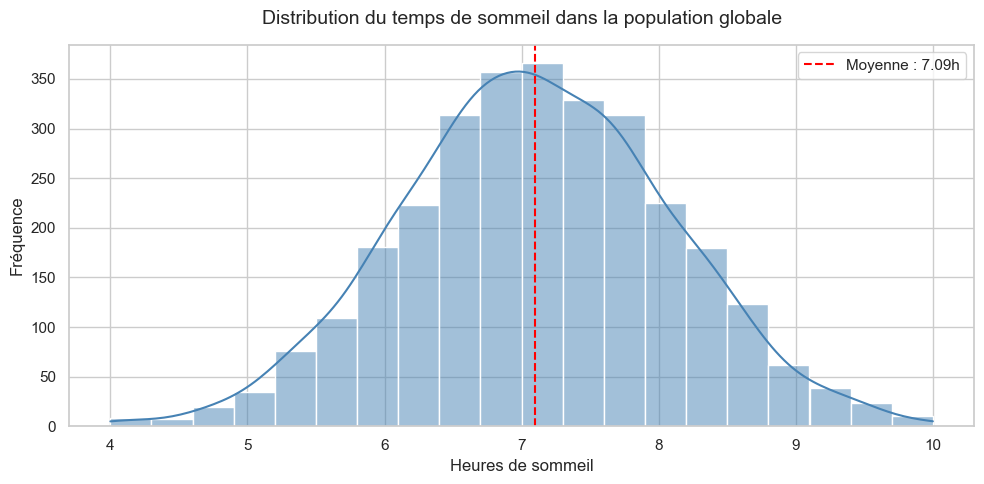

In [78]:
def tracer_distribution_sommeil(df):
    plt.figure(figsize=(10, 5))
    
    moyenne_sommeil = df['sleep_hours'].mean()
    
    sns.histplot(data=df, x='sleep_hours', kde=True, bins=20, color='steelblue')
    plt.axvline(moyenne_sommeil, color='red', linestyle='--', label=f"Moyenne : {moyenne_sommeil:.2f}h")

    plt.title("Distribution du temps de sommeil dans la population globale", fontsize=14, pad=15)
    plt.xlabel("Heures de sommeil")
    plt.ylabel("Fréquence")
    plt.legend()
    plt.tight_layout()
    plt.show()

tracer_distribution_sommeil(df_act)

**Analyse :** La variable cible suit une distribution normale, centrée sur 7,09 heures, avec une dispersion allant de 4 à 9 heures. L'enjeu de notre analyse est d'identifier quelles variables expliquent ces écarts.

## 2. Évaluation globale des corrélations linéaires

Nous appliquons une matrice de corrélation de Pearson sur les variables continues pour isoler immédiatement les facteurs d'influence primaires.

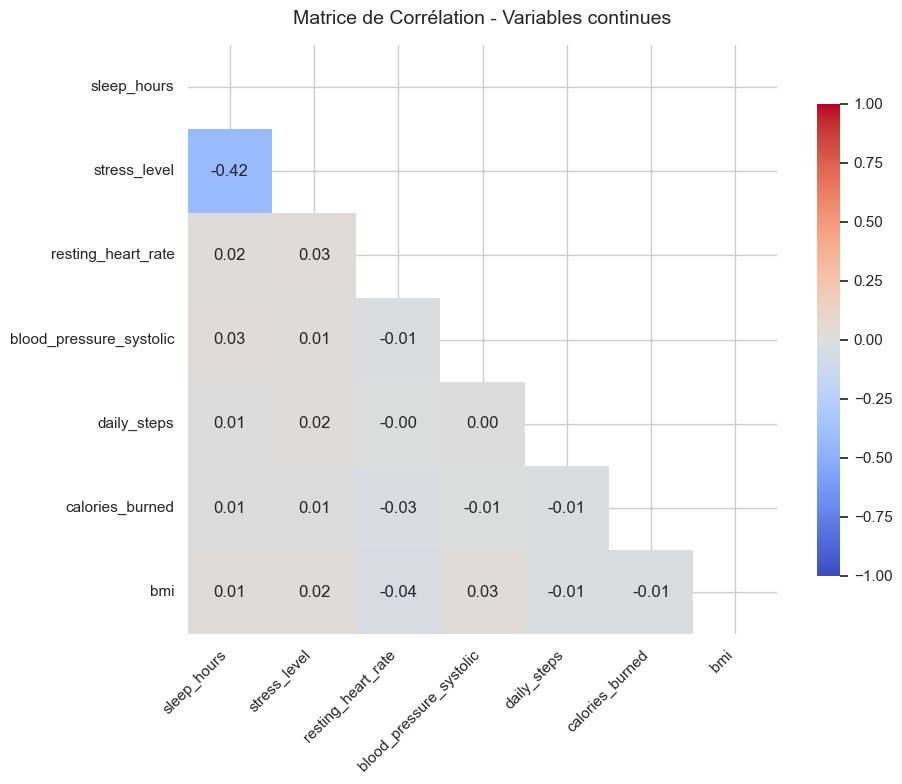

In [79]:
def tracer_matrice_correlation(df):
    cols = ['sleep_hours', 'stress_level', 'resting_heart_rate', 
            'blood_pressure_systolic', 'daily_steps', 'calories_burned', 'bmi']
    
    corr = df[cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
                vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8})

    plt.title("Matrice de Corrélation - Variables continues", fontsize=14, pad=15)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

tracer_matrice_correlation(df_act)

**Analyse :** * **Le facteur dominant :** Le niveau de stress présente une forte corrélation négative (-0.42). 
* **Le bruit statistique :** Les autres variables (rythme cardiaque, pas quotidiens, calories) affichent des corrélations proches de zéro. Cela n'indique pas qu'elles sont inutiles, mais que leur relation avec le sommeil n'est pas une simple ligne droite. Explorons chaque piste.

## 3. Le poids écrasant du Stress Psychologique

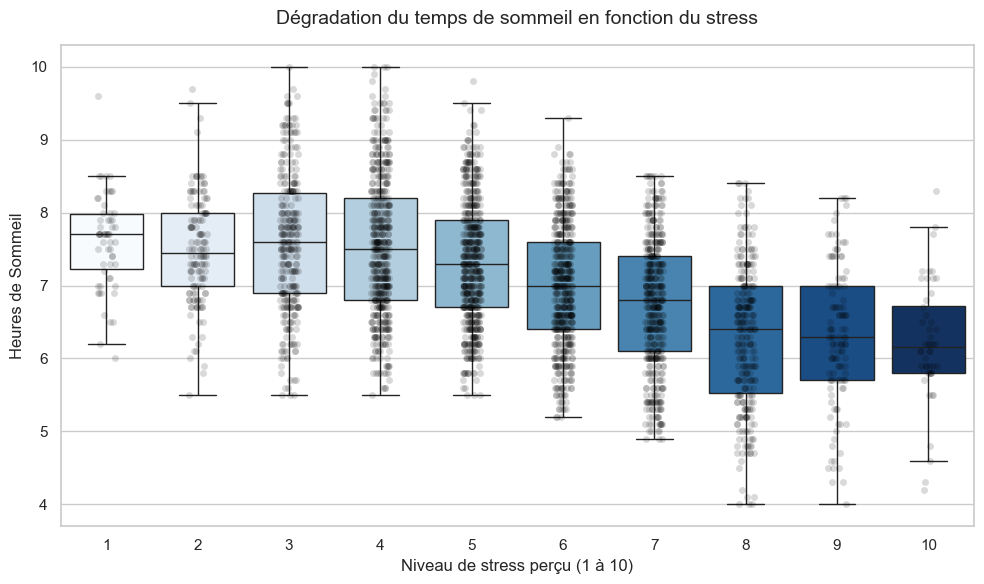

In [81]:
def tracer_sommeil_vs_stress(df):
    plt.figure(figsize=(10, 6))

    sns.boxplot(data=df, x='stress_level', y='sleep_hours', 
                hue='stress_level', palette='Blues', 
                showfliers=False, legend=False)
    
    # Le stripplot permet de voir la densité réelle des points
    sns.stripplot(data=df, x='stress_level', y='sleep_hours', 
                  color='black', alpha=0.15, jitter=True)

    plt.title("Dégradation du temps de sommeil en fonction du stress", fontsize=14, pad=15)
    plt.xlabel("Niveau de stress perçu (1 à 10)")
    plt.ylabel("Heures de Sommeil")
    
    plt.tight_layout()
    plt.show()

tracer_sommeil_vs_stress(df_act)

**Analyse :** Visuellement, l'effet est indiscutable. On observe une baisse progressive et continue de la médiane de sommeil à mesure que l'indice de stress augmente, on en conclut que le stress est notre meilleur prédicteur.

## 4. Le volume de sport influence-t-il la récupération ?

La matrice de corrélation indiquait un lien faible pour les pas et les calories. Vérifions cela avec des droites de régression.

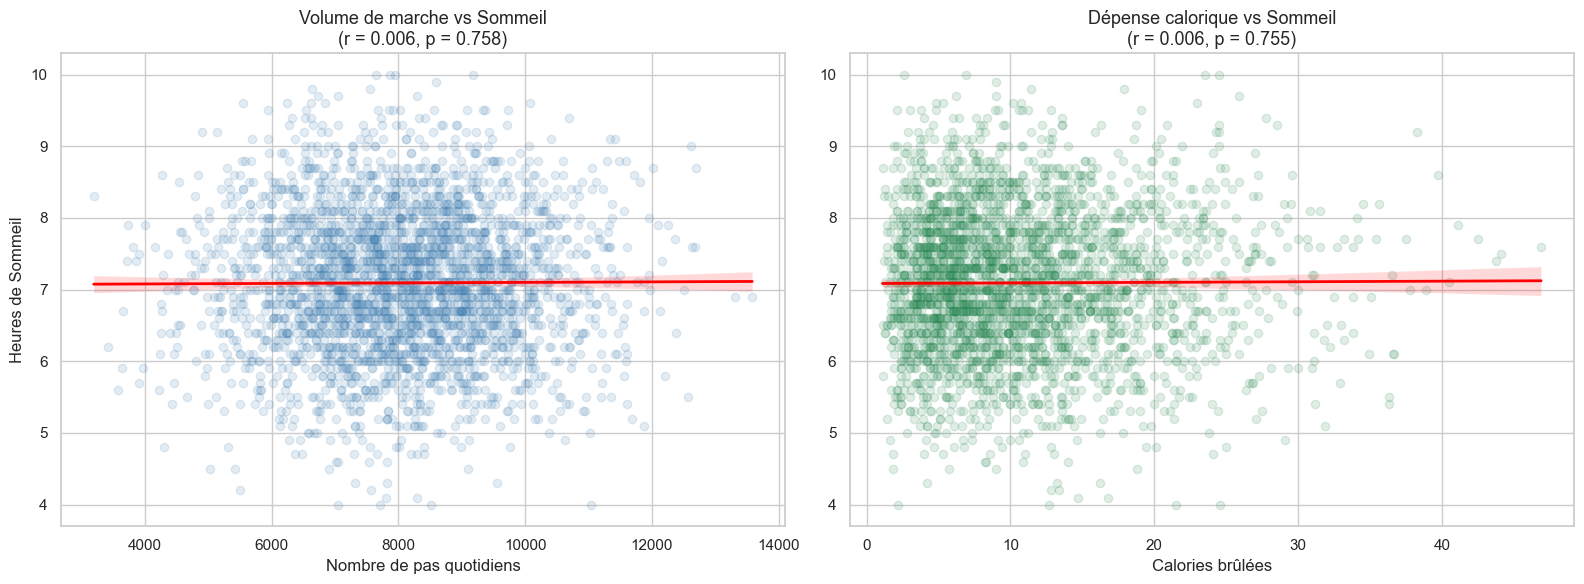

In [82]:
from scipy import stats

def tracer_comparaison_activite(df):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Calcul des stats pour les pas
    r_steps, p_steps = stats.pearsonr(df['daily_steps'], df['sleep_hours'])
    
    sns.regplot(ax=ax1, data=df, x='daily_steps', y='sleep_hours',
                scatter_kws={'alpha': 0.15, 'color': 'steelblue'}, 
                line_kws={'color': 'red', 'lw': 2})
    ax1.set_title(f"Volume de marche vs Sommeil\n(r = {r_steps:.3f}, p = {p_steps:.3f})", fontsize=13)
    ax1.set_xlabel("Nombre de pas quotidiens")
    ax1.set_ylabel("Heures de Sommeil")

    # Calcul des stats pour les calories
    r_cal, p_cal = stats.pearsonr(df['calories_burned'], df['sleep_hours'])

    sns.regplot(ax=ax2, data=df, x='calories_burned', y='sleep_hours',
                scatter_kws={'alpha': 0.15, 'color': 'seagreen'}, 
                line_kws={'color': 'red', 'lw': 2})
    ax2.set_title(f"Dépense calorique vs Sommeil\n(r = {r_cal:.3f}, p = {p_cal:.3f})", fontsize=13)
    ax2.set_xlabel("Calories brûlées")
    ax2.set_ylabel("")

    plt.tight_layout()
    plt.show()

tracer_comparaison_activite(df_act)

**Analyse :** Les nuages de points sont totalement dispersés et les droites de régression sont plates. Dans cette population, s'épuiser à faire 15 000 pas ou brûler énormément de calories ne garantit pas une nuit plus longue. Le volume brut n'est pas le bon indicateur.

## 5. La nuance par la Morphologie et l'Intensité

Si le volume de pas ne compte pas, regardons la qualité de l'effort (Intensité) et la corpulence de l'individu (IMC) grâce à des graphiques en violon.

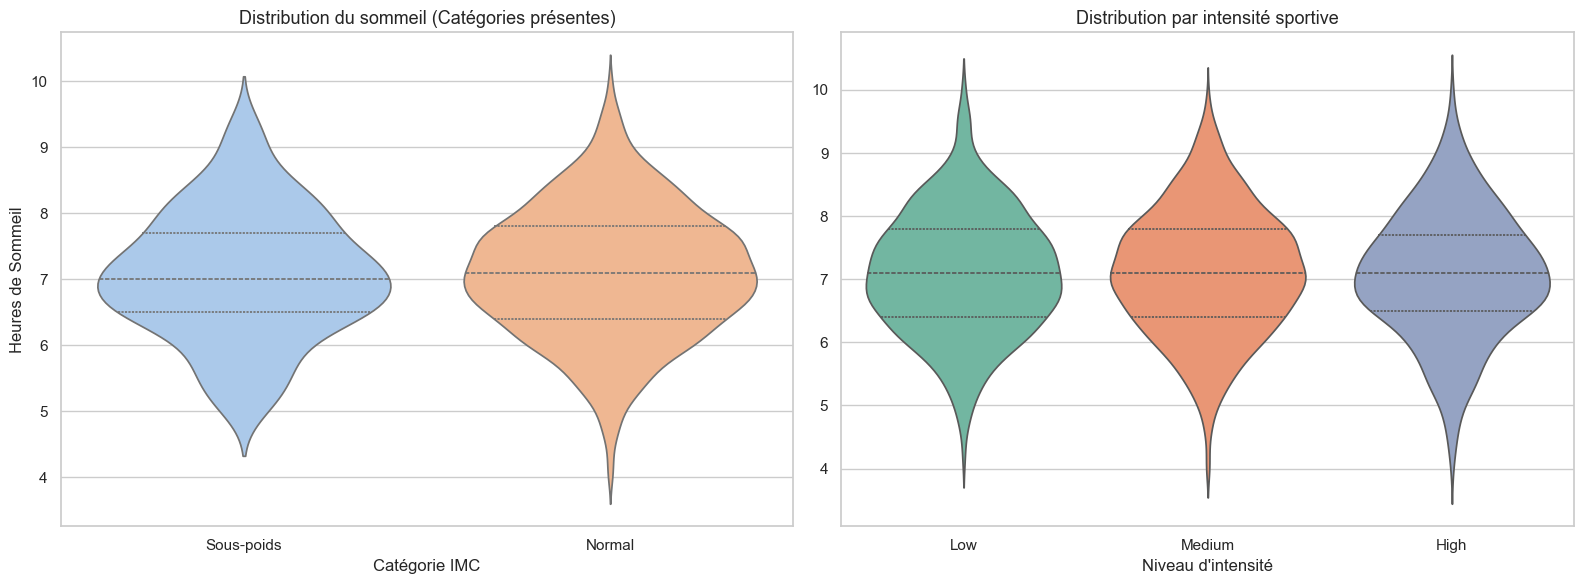

In [85]:
def tracer_nuances_filtrees(df):
    # On ne garde que les catégories qui ont au moins un individu
    df_exists = df[df['bmi_category'].isin(['Sous-poids', 'Normal'])].copy()
    # On enlève les catégories vides pour que le graphique ne laisse pas de place vide
    df_exists['bmi_category'] = df_exists['bmi_category'].cat.remove_unused_categories()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Graphique IMC filtré
    sns.violinplot(ax=ax1, data=df_exists, x='bmi_category', y='sleep_hours', 
                   hue='bmi_category', palette='pastel', inner='quartile', legend=False)
    ax1.set_title("Distribution du sommeil (Catégories présentes)", fontsize=13)
    ax1.set_xlabel("Catégorie IMC")
    ax1.set_ylabel("Heures de Sommeil")

    # Graphique Intensité (inchangé car les 3 groupes existent)
    ordre = ['Low', 'Medium', 'High']
    sns.violinplot(ax=ax2, data=df, x='intensity', y='sleep_hours', 
                   order=ordre, hue='intensity', palette='Set2', inner='quartile', legend=False)
    ax2.set_title("Distribution par intensité sportive", fontsize=13)
    ax2.set_xlabel("Niveau d'intensité")
    ax2.set_ylabel("")

    plt.tight_layout()
    plt.show()

tracer_nuances_filtrees(df_act)

## Analyse exploratoire des données de sommeil

### Morphologie (Biais d'échantillonnage)
L’échantillon étudié est très homogène, composé quasi exclusivement de profils **"Normaux"** ($n=2805$).  
L’absence totale d’individus en surpoids ou obèses empêche d’évaluer l’impact de ces morphologies sur le sommeil.  

On observe cependant que les profils **"Sous-poids"** présentent une distribution très similaire aux profils normaux, avec une **médiane centrée sur 7 heures** de sommeil.

### Intensité d’activité
La **modération** apparaît comme le facteur clé de la régularité du sommeil.  
- L’intensité **"Medium"** présente la plus forte densité autour de 7 heures (le violon est plus ventru au centre).  
- À l’inverse, l’intensité **"High"** montre une variance plus importante, avec un étalement vers des durées de sommeil plus courtes.  
  Cela suggère qu’un effort trop intense peut devenir perturbateur pour certains individus.

## 6. L'impact de la santé cardiovasculaire

Dans de précédentes études, la tension artérielle s'est révélée être un marqueur intéressant. Testons cette hypothèse sur notre base de données.

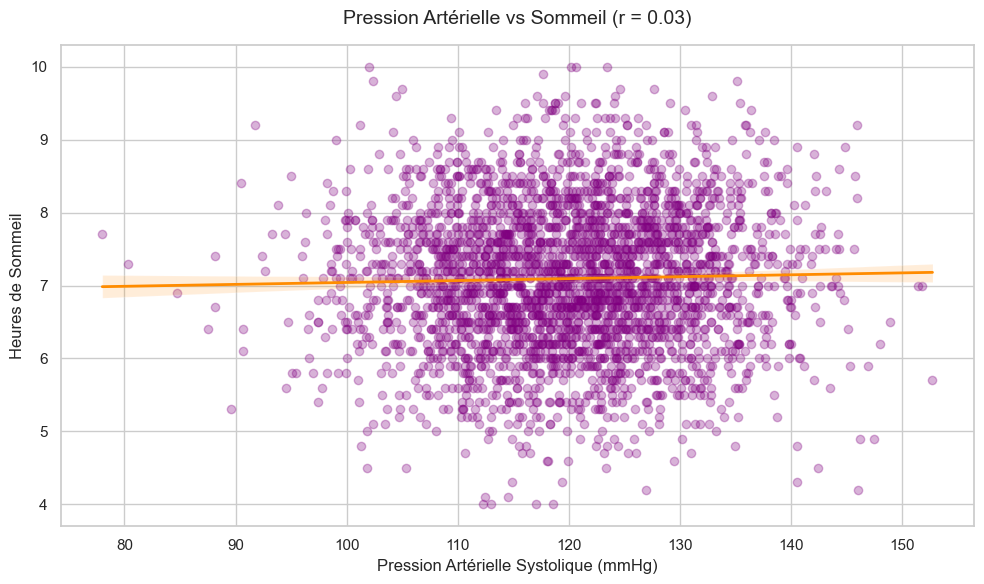

In [90]:
from scipy.stats import pearsonr

def analyser_cardio_sommeil(df):
    plt.figure(figsize=(10, 6))
    
    # Calcul de la corrélation de Pearson
    corr, _ = pearsonr(df['blood_pressure_systolic'], df['sleep_hours'])
    
    sns.regplot(data=df, x='blood_pressure_systolic', y='sleep_hours',
                scatter_kws={'alpha': 0.3, 'color': 'purple'}, 
                line_kws={'color': 'darkorange', 'lw': 2})

    plt.title(f"Pression Artérielle vs Sommeil (r = {corr:.2f})", fontsize=14, pad=15)
    plt.xlabel("Pression Artérielle Systolique (mmHg)")
    plt.ylabel("Heures de Sommeil")
    
    plt.tight_layout()
    plt.show()

analyser_cardio_sommeil(df_act)

## Analyse exploratoire : Pression artérielle vs Sommeil

### Absence de corrélation
Comme suggéré par la matrice de corrélation ($r = 0.03$), la droite de régression (en orange) est quasi plate.

### Observation
La pression systolique n’apparaît pas, dans ce jeu de données, comme un indicateur fiable de la durée du sommeil.  
Un individu avec une tension de **110 mmHg** peut dormir autant qu’un individu à **140 mmHg**.

### Conclusion statistique
Aucun modèle linéaire ne peut être établi entre ces deux variables.  
Dans ce dataset, la santé cardiovasculaire semble **indépendante du temps passé au lit**.

## 7. Vérification croisée : La loi du Stress est-elle universelle ?

Nous avons défini que le stress est le prédicteur numéro un dans notre base. Pour nous assurer que ce n'est pas un biais de notre jeu de données, vérifions si cette loi se confirme dans notre journal clinique externe (`sommeil_logs.csv`).

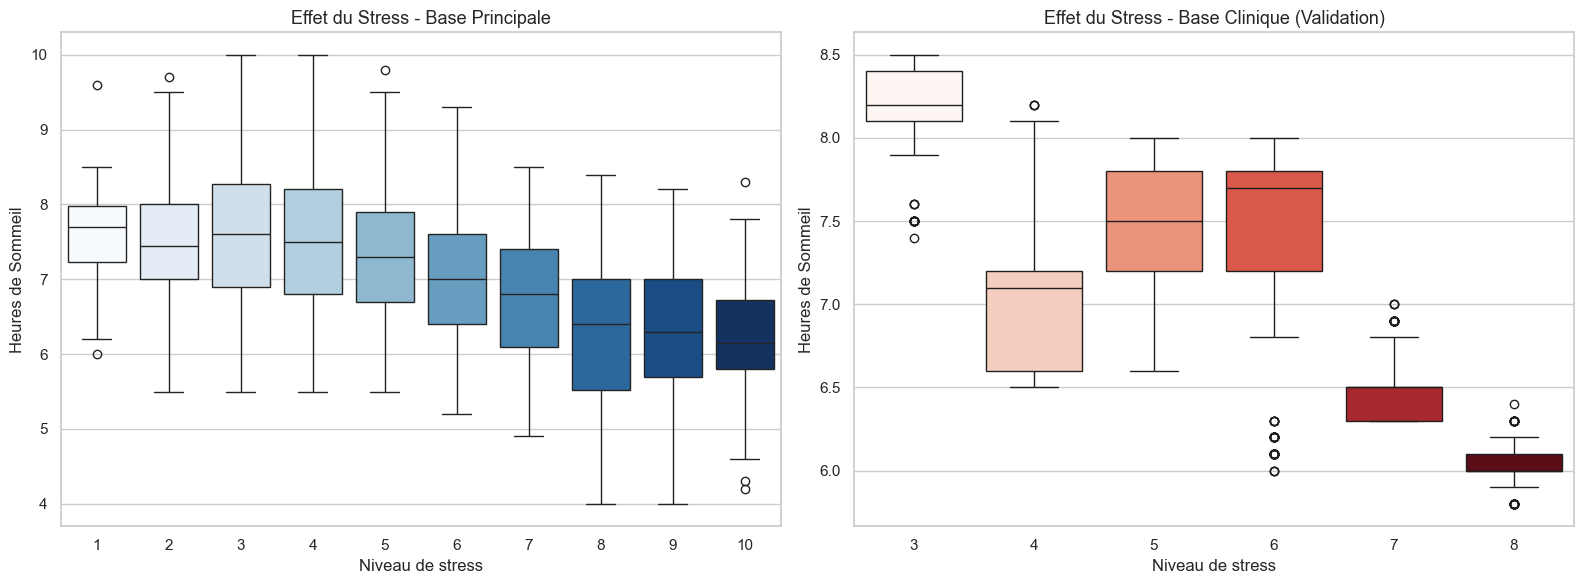

In [94]:
def verifier_loi_stress(df_principal, df_clinique):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Comparaison de la base principale (Grand Public)
    sns.boxplot(ax=axes[0], data=df_principal, x='stress_level', y='sleep_hours', 
                hue='stress_level', palette='Blues', legend=False)
    axes[0].set_title("Effet du Stress - Base Principale", fontsize=13)
    axes[0].set_xlabel("Niveau de stress")
    axes[0].set_ylabel("Heures de Sommeil")

    # Comparaison de la base clinique (Validation)
    sns.boxplot(ax=axes[1], data=df_clinique, x='stress_level', y='sleep_duration', 
                hue='stress_level', palette='Reds', legend=False)
    axes[1].set_title("Effet du Stress - Base Clinique (Validation)", fontsize=13)
    axes[1].set_xlabel("Niveau de stress")
    axes[1].set_ylabel("Heures de Sommeil")

    plt.tight_layout()
    plt.show()

verifier_loi_stress(df_act, df_som)


### Tendance générale
L’analyse des deux bases de données confirme la même tendance : le **stress agit comme un facteur qui réduit mécaniquement le temps de sommeil**.

### Observations spécifiques
- La **base clinique** montre une sensibilité plus marquée, avec une **chute plus raide** de la durée du sommeil.  
- Cela valide la robustesse du **prédicteur principal** basé sur le niveau de stress.

## 8. Viabilité du projet : La base cible est-elle compatible ?

L'objectif final du projet sera de déployer un algorithme sur la base `Fitness.csv` (qui ne possède pas la donnée de sommeil). Pour que cela soit scientifiquement valide, la population cible doit correspondre à notre population d'entraînement.

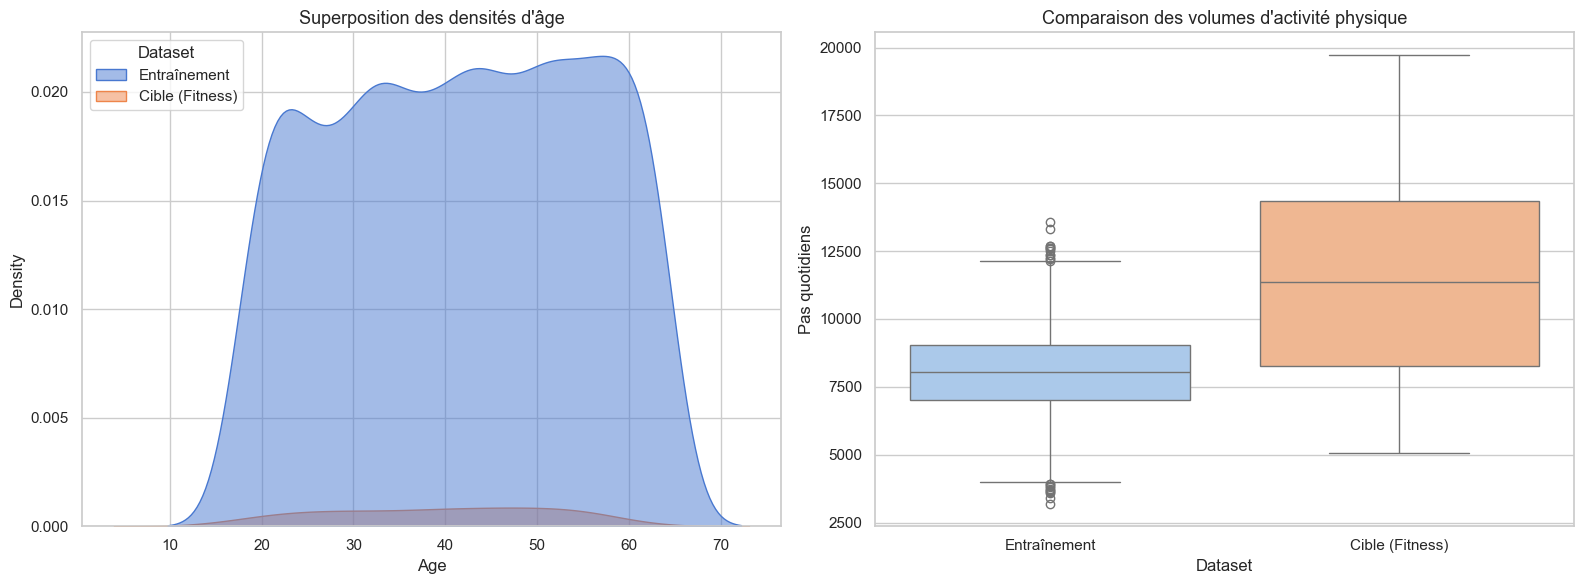

In [ ]:
def verifier_compatibilite_cible(df_act, df_fit):

    df1 = pd.DataFrame({'Dataset': 'Entraînement', 'Age': df_act['age'], 'Pas': df_act['daily_steps']})
    df2 = pd.DataFrame({'Dataset': 'Cible (Fitness)', 'Age': df_fit['age'], 'Pas': df_fit['daily_steps']})
    df_total = pd.concat([df1, df2], ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

  
    sns.kdeplot(ax=axes[0], data=df_total, x='Age', hue='Dataset', fill=True, palette='muted', alpha=0.5)
    axes[0].set_title("Superposition des densités d'âge", fontsize=13)

   
    sns.boxplot(ax=axes[1], data=df_total, x='Dataset', y='Pas', hue='Dataset', palette='pastel', legend=False)
    axes[1].set_title("Comparaison des volumes d'activité physique", fontsize=13)
    axes[1].set_ylabel("Pas quotidiens")

    plt.tight_layout()
    plt.show()

verifier_compatibilite_cible(df_act, df_fit)

**Analyse :** Les distributions d'âge et les médianes d'activité physique démontrent une forte homogénéité entre les bases. Ce résultat valide notre stratégie : les déductions tirées de la base d'entraînement seront applicables à la base cible.

---
## Conclusion Générale de la DataViz

L'exploration de la base `activite_globale` nous a permis de décoder les déterminants du sommeil :
1. **L'indicateur absolu :** Le niveau de stress perçu dicte lourdement la durée du repos. 
2. **La nuance de l'effort :** Le volume de sport (pas, calories) ne suffit pas à expliquer le sommeil. C'est l'intensité de l'effort et la morphologie qui apportent de la nuance.
3. **Une stratégie solide :** Nos trois jeux de données sont statistiquement compatibles et racontent la même histoire biologique.

Le terrain est désormais parfaitement préparé pour concevoir une Intelligence Artificielle prédictive.